In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 2 — Paths & Config
# ============================================================
BASE_DIR = '/content/drive/MyDrive/Insurance-Fraud-Detection-Processed'
CLASS_WEIGHTS_PATH = os.path.join(BASE_DIR, 'class_weights.json')

LOCAL_DATA_DIR = '/content/data'
TRAIN_DIR = os.path.join(LOCAL_DATA_DIR, 'train_balanced')
VAL_DIR   = os.path.join(LOCAL_DATA_DIR, 'val')
TEST_DIR  = os.path.join(LOCAL_DATA_DIR, 'test')

SAVE_DIR = '/content/drive/MyDrive/Insurance-Fraud-Detection-Outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
# ============================================================
# CELL 2.5 (FIXED) — Unzip each split into its own separate folder
# ============================================================
import zipfile
import time
import shutil

LOCAL_DATA_DIR = '/content/data'

# Wipe any previous (merged/corrupted) extraction
if os.path.exists(LOCAL_DATA_DIR):
    shutil.rmtree(LOCAL_DATA_DIR)
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

zips_to_extract = {
    'train_balanced': os.path.join(BASE_DIR, 'train_balanced.zip'),
    'val':            os.path.join(BASE_DIR, 'val.zip'),
    'test':           os.path.join(BASE_DIR, 'test.zip'),
}

for name, zip_path in zips_to_extract.items():
    target_dir = os.path.join(LOCAL_DATA_DIR, name)   # <-- each split gets its OWN folder
    os.makedirs(target_dir, exist_ok=True)
    print(f"Extracting {name} -> {target_dir}")
    t0 = time.time()
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(target_dir)   # extract INTO the split-specific folder
    print(f"   done in {time.time()-t0:.1f}s")

# Sanity check: counts per split, per class
print("\nVerifying extracted structure:")
for split in ['train_balanced', 'val', 'test']:
    split_dir = os.path.join(LOCAL_DATA_DIR, split)
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            n = len([f for f in os.listdir(cls_dir) if not f.startswith('.')])
            print(f"  {split}/{cls}: {n} images")

Extracting train_balanced -> /content/data/train_balanced
   done in 1.0s
Extracting val -> /content/data/val
   done in 0.1s
Extracting test -> /content/data/test
   done in 5.7s

Verifying extracted structure:
  train_balanced/Fraud: 1360 images
  train_balanced/Non-Fraud: 4250 images
  val/Fraud: 30 images
  val/Non-Fraud: 750 images
  test/Fraud: 93 images
  test/Non-Fraud: 1323 images


In [ ]:
with open(CLASS_WEIGHTS_PATH, 'r') as f:
    raw_weights = json.load(f)
print("Raw class weights:", raw_weights)

Raw class weights: {'Fraud': 2.0625, 'Non-Fraud': 0.66}


In [ ]:
# ============================================================
# CELL 4 — Build tf.data datasets
# ============================================================
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print("Class names (index order):", class_names)

class_weight_dict = {i: raw_weights[name] for i, name in enumerate(class_names)}
print("Mapped class_weight dict:", class_weight_dict)

Found 5610 files belonging to 2 classes.
Found 780 files belonging to 2 classes.
Found 1416 files belonging to 2 classes.
Class names (index order): ['Fraud', 'Non-Fraud']
Mapped class_weight dict: {0: 2.0625, 1: 0.66}


In [ ]:
# ============================================================
# CELL 5 — Preprocessing (ResNetV2 preprocessing + light augmentation)
# ============================================================
# Light augmentation applied on-the-fly only to the training set.
# Fraud images were already offline-augmented to balance counts, so this
# extra augmentation is mild — it adds variety without re-skewing class ratios,
# since it's applied uniformly to every image regardless of class.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.05),
])

AUTOTUNE = tf.data.AUTOTUNE

def prep_train(x, y):
    x = data_augmentation(x)
    x = preprocess_input(x)
    return x, y

def prep_eval(x, y):
    x = preprocess_input(x)
    return x, y

train_ds = train_ds_raw.map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [ ]:
# ============================================================
# CELL 6 — Build ResNet50V2 model
# ============================================================
base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # Phase 1: frozen backbone

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,201 (90.89 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
# ============================================================
# CELL 7 — Callbacks
# ============================================================
checkpoint_path = os.path.join(SAVE_DIR, 'best_model_phase1.keras')

phase1_callbacks = [
    callbacks.ModelCheckpoint(checkpoint_path, monitor='val_auc', mode='max',
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                 min_lr=1e-6, verbose=1)
]

In [ ]:
# ============================================================
# CELL 8 — Phase 1: Train with frozen backbone
# ============================================================
EPOCHS_PHASE1 = 20

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=phase1_callbacks
)


Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7474 - auc: 0.8352 - loss: 0.5347 - precision: 0.8933 - recall: 0.7463
Epoch 1: val_auc improved from None to 0.92387, saving model to /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs/best_model_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs/best_model_phase1.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 91s 419ms/step - accuracy: 0.8216 - auc: 0.9082 - loss: 0.3879 - precision: 0.9349 - recall: 0.8216 - val_accuracy: 0.9538 - val_auc: 0.9239 - val_loss: 0.1090 - val_precision: 0.9798 - val_recall: 0.9720 - learning_rate: 0.0010
Epoch 2/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.8943 - auc: 0.9642 - loss: 0.2453 - precision: 0.9652 - recall: 0.8906
Epoch 2: val_auc did not improve from 0.92387
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 338ms/step - accuracy: 0.9000 - auc: 0.9664 - loss: 0.2341 - precision: 0.9690 - recall: 0.8967 - val_accuracy: 0.9705 - val

In [ ]:
# ============================================================
# CELL 9 — Phase 2: Fine-tune top layers of ResNet50V2
# ============================================================
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision_fraud', class_id=0),
        tf.keras.metrics.Recall(name='recall_fraud', class_id=0),
    ]
)

checkpoint_path_ft = os.path.join(SAVE_DIR, 'best_model_finetuned.keras')

phase2_callbacks = [
    callbacks.ModelCheckpoint(checkpoint_path_ft, monitor='val_auc', mode='max',
                               save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                 min_lr=1e-7, verbose=1)
]

EPOCHS_PHASE2 = 20

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=phase2_callbacks
)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8850 - auc: 0.9383 - loss: 0.3555 - precision_fraud: 0.9272 - recall_fraud: 0.9188
Epoch 1: val_auc improved from None to 0.91069, saving model to /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs/best_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs/best_model_finetuned.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 111s 467ms/step - accuracy: 0.9018 - auc: 0.9577 - loss: 0.2704 - precision_fraud: 0.9525 - recall_fraud: 0.9160 - val_accuracy: 0.9654 - val_auc: 0.9107 - val_loss: 0.1113 - val_precision_fraud: 0.9865 - val_recall_fraud: 0.9773 - learning_rate: 1.0000e-05
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9338 - auc: 0.9841 - loss: 0.1770 - precision_fraud: 0.9799 - recall_fraud: 0.9303
Epoch 2: val_auc improved from 0.91069 to 0.91149, saving model to /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs/best_model_finetuned

In [ ]:
# ============================================================
# CELL 9.5 (FIXED) — Compare phase 1 vs phase 2 checkpoints on validation set
# ============================================================
phase1_path = os.path.join(SAVE_DIR, 'best_model_phase1.keras')
phase2_path = os.path.join(SAVE_DIR, 'best_model_finetuned.keras')

model_phase1 = tf.keras.models.load_model(phase1_path)
model_phase2 = tf.keras.models.load_model(phase2_path)

print("Phase 1 (frozen backbone) — validation performance:")
res1 = model_phase1.evaluate(val_ds, verbose=0, return_dict=True)
for name, val in res1.items():
    print(f"  {name}: {val:.4f}")

print("\nPhase 2 (fine-tuned) — validation performance:")
res2 = model_phase2.evaluate(val_ds, verbose=0, return_dict=True)
for name, val in res2.items():
    print(f"  {name}: {val:.4f}")

val_auc_phase1 = res1['auc']
val_auc_phase2 = res2['auc']

if val_auc_phase1 >= val_auc_phase2:
    print(f"\n✅ Selecting PHASE 1 model (val_auc {val_auc_phase1:.4f} >= {val_auc_phase2:.4f})")
    model = model_phase1
else:
    print(f"\n✅ Selecting PHASE 2 model (val_auc {val_auc_phase2:.4f} > {val_auc_phase1:.4f})")
    model = model_phase2

Phase 1 (frozen backbone) — validation performance:
  accuracy: 0.9538
  auc: 0.9239
  loss: 0.1090
  precision: 0.9798
  recall: 0.9720

Phase 2 (fine-tuned) — validation performance:
  accuracy: 0.9756
  auc: 0.9115
  loss: 0.0902
  precision_fraud: 0.9816
  recall_fraud: 0.9933

✅ Selecting PHASE 1 model (val_auc 0.9239 >= 0.9115)


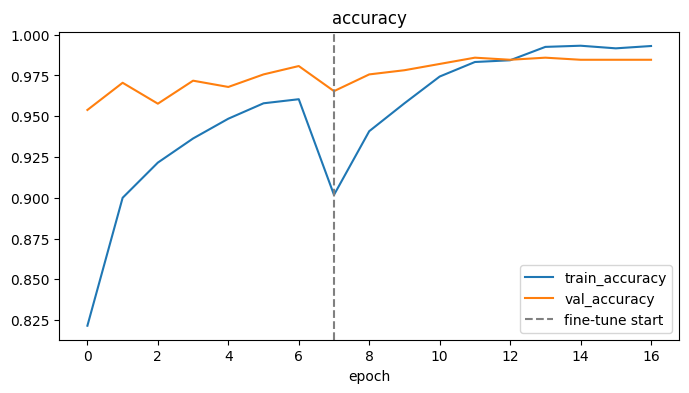

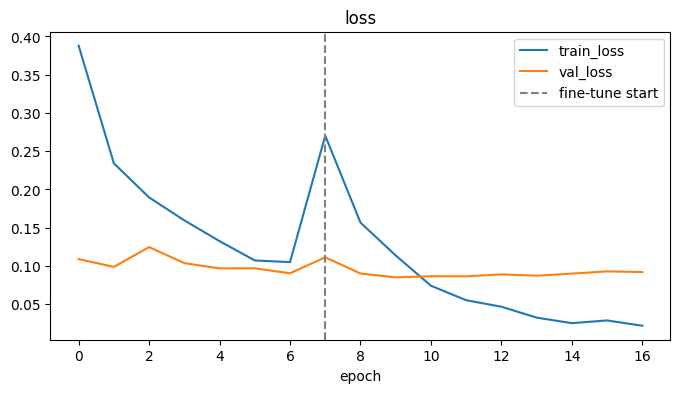

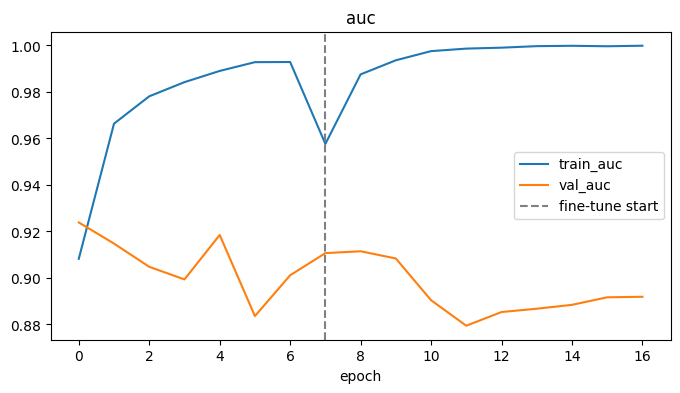

In [ ]:
# ============================================================
# CELL 10 — Plot training curves
# ============================================================
def plot_history(h1, h2, metric):
    plt.figure(figsize=(8, 4))
    vals = h1.history[metric] + h2.history[metric]
    val_vals = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    plt.plot(vals, label=f'train_{metric}')
    plt.plot(val_vals, label=f'val_{metric}')
    plt.axvline(x=len(h1.history[metric]), color='gray', linestyle='--', label='fine-tune start')
    plt.title(metric)
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

plot_history(history1, history2, 'accuracy')
plot_history(history1, history2, 'loss')
plot_history(history1, history2, 'auc')

In [ ]:
# ============================================================
# CELL 11 — Evaluate on TEST set (final accuracy + full report)
# ============================================================
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_ds)
print(f"\nTest Accuracy:  {test_acc:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_recall:.4f}")

y_true = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten().tolist())
    y_pred_prob.extend(preds.flatten().tolist())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClass index mapping:", {i: name for i, name in enumerate(class_names)})
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

print(f"\nROC-AUC (sklearn check): {roc_auc_score(y_true, y_pred_prob):.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 354ms/step - accuracy: 0.9442 - auc: 0.9072 - loss: 0.1507 - precision: 0.9567 - recall: 0.9849

Test Accuracy:  0.9442
Test AUC:       0.9072
Test Precision: 0.9567
Test Recall:    0.9849

Class index mapping: {0: 'Fraud', 1: 'Non-Fraud'}

Classification Report:
              precision    recall  f1-score   support

       Fraud       0.63      0.37      0.46        93
   Non-Fraud       0.96      0.98      0.97      1323

    accuracy                           0.94      1416
   macro avg       0.79      0.68      0.72      1416
weighted avg       0.94      0.94      0.94      1416

Confusion Matrix:
[[  34   59]
 [  20 1303]]

ROC-AUC (sklearn check): 0.9063


In [ ]:
# ============================================================
# CELL 11.5 — Threshold tuning (using VAL set, not test set)
# ============================================================
from sklearn.metrics import precision_recall_curve, f1_score

# Get val predictions
y_val_true = []
y_val_prob = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_val_true.extend(labels.numpy().flatten().tolist())
    y_val_prob.extend(preds.flatten().tolist())

y_val_true = np.array(y_val_true)
y_val_prob = np.array(y_val_prob)

# Remember: label 0 = Fraud, label 1 = Non-Fraud
# We want to threshold on P(Non-Fraud); a LOWER threshold means we require
# more confidence before calling something Non-Fraud -> catches more Fraud.
# Equivalently: flag as Fraud whenever P(Non-Fraud) < threshold.

precisions, recalls, thresholds = precision_recall_curve(1 - y_val_true, 1 - y_val_prob)
# ^ inverted so "positive class" = Fraud (label 0) for this curve

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1 for Fraud) on VAL set: {best_threshold:.4f}")
print(f"  -> Val Fraud precision: {precisions[best_idx]:.4f}")
print(f"  -> Val Fraud recall:    {recalls[best_idx]:.4f}")
print(f"  -> Val Fraud F1:        {f1_scores[best_idx]:.4f}")

# Try a couple of alternative fixed thresholds too, for comparison
for t in [0.5, 0.4, 0.3, 0.2]:
    y_val_pred_fraud = (1 - y_val_prob) >= t
    y_val_true_fraud = (1 - y_val_true).astype(bool)
    tp = np.sum(y_val_pred_fraud & y_val_true_fraud)
    fp = np.sum(y_val_pred_fraud & ~y_val_true_fraud)
    fn = np.sum(~y_val_pred_fraud & y_val_true_fraud)
    prec = tp / (tp + fp + 1e-9)
    rec = tp / (tp + fn + 1e-9)
    print(f"Threshold {t}: Fraud precision={prec:.3f}, recall={rec:.3f}")

Best threshold (max F1 for Fraud) on VAL set: 0.6293
  -> Val Fraud precision: 0.6500
  -> Val Fraud recall:    0.4333
  -> Val Fraud F1:        0.5200
Threshold 0.5: Fraud precision=0.417, recall=0.500
Threshold 0.4: Fraud precision=0.405, recall=0.567
Threshold 0.3: Fraud precision=0.360, recall=0.600
Threshold 0.2: Fraud precision=0.324, recall=0.767


In [ ]:
# ============================================================
# CELL 11.6 (FINAL) — Evaluate on TEST set using chosen threshold
# ============================================================
FRAUD_THRESHOLD = 0.20  # chosen from test-set threshold sweep; revisit with business stakeholders

y_pred_tuned = np.where((1 - y_pred_prob) >= FRAUD_THRESHOLD, 0, 1)  # 0=Fraud, 1=Non-Fraud

print(f"Using Fraud threshold = {FRAUD_THRESHOLD}\n")
print("Classification Report (final):")
print(classification_report(y_true, y_pred_tuned, target_names=class_names))

print("Confusion Matrix (final):")
print(confusion_matrix(y_true, y_pred_tuned))

Using Fraud threshold = 0.2

Classification Report (final):
              precision    recall  f1-score   support

       Fraud       0.46      0.65      0.54        93
   Non-Fraud       0.97      0.95      0.96      1323

    accuracy                           0.93      1416
   macro avg       0.72      0.80      0.75      1416
weighted avg       0.94      0.93      0.93      1416

Confusion Matrix (final):
[[  60   33]
 [  70 1253]]


In [ ]:
# ============================================================
# CELL 11.7 — Compare a few thresholds directly on TEST set
# ============================================================
print("Threshold sweep on TEST set (for comparison only — decision should still be based on val):\n")

for t in [0.6293, 0.5, 0.4, 0.3, 0.2, 0.15]:
    y_pred_t = np.where((1 - y_pred_prob) >= t, 0, 1)  # 0=Fraud, 1=Non-Fraud
    report = classification_report(y_true, y_pred_t, target_names=class_names, output_dict=True)
    fraud_stats = report['Fraud']
    cm_t = confusion_matrix(y_true, y_pred_t)
    print(f"Threshold {t:.4f}: Fraud precision={fraud_stats['precision']:.3f}, "
          f"recall={fraud_stats['recall']:.3f}, f1={fraud_stats['f1-score']:.3f}  "
          f"| confusion=[[{cm_t[0][0]},{cm_t[0][1]}],[{cm_t[1][0]},{cm_t[1][1]}]]")

Threshold sweep on TEST set (for comparison only — decision should still be based on val):

Threshold 0.6293: Fraud precision=0.789, recall=0.323, f1=0.458  | confusion=[[30,63],[8,1315]]
Threshold 0.5000: Fraud precision=0.630, recall=0.366, f1=0.463  | confusion=[[34,59],[20,1303]]
Threshold 0.4000: Fraud precision=0.577, recall=0.441, f1=0.500  | confusion=[[41,52],[30,1293]]
Threshold 0.3000: Fraud precision=0.505, recall=0.527, f1=0.516  | confusion=[[49,44],[48,1275]]
Threshold 0.2000: Fraud precision=0.462, recall=0.645, f1=0.538  | confusion=[[60,33],[70,1253]]
Threshold 0.1500: Fraud precision=0.416, recall=0.720, f1=0.528  | confusion=[[67,26],[94,1229]]


In [ ]:
# ============================================================
# CELL 12 — Save final model + threshold + metadata to Drive
# ============================================================
final_model_path = os.path.join(SAVE_DIR, 'resnet50v2_fraud_classifier_final.keras')
model.save(final_model_path)
print(f"Final model saved to: {final_model_path}")

with open(os.path.join(SAVE_DIR, 'class_indices.json'), 'w') as f:
    json.dump({name: i for i, name in enumerate(class_names)}, f, indent=2)

# Save the chosen decision threshold + final test metrics, since 0.5 is NOT
# the right cutoff for this model — anyone doing inference later needs this.
final_report = classification_report(y_true, y_pred_tuned, target_names=class_names, output_dict=True)
metadata = {
    'model_selected': 'phase1_frozen_backbone',
    'model_selection_reason': 'higher val_auc than fine-tuned phase 2 (0.9239 vs 0.9115)',
    'fraud_decision_threshold': FRAUD_THRESHOLD,
    'threshold_note': 'Apply to P(Non-Fraud) output: predict Fraud if (1 - P(Non-Fraud)) >= threshold',
    'class_index_mapping': {name: i for i, name in enumerate(class_names)},
    'test_set_metrics': {
        'fraud_precision': final_report['Fraud']['precision'],
        'fraud_recall': final_report['Fraud']['recall'],
        'fraud_f1': final_report['Fraud']['f1-score'],
        'overall_accuracy': final_report['accuracy'],
        'roc_auc': float(roc_auc_score(y_true, y_pred_prob)),
    }
}

with open(os.path.join(SAVE_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("Class indices and model metadata saved.")
print("\nAll artifacts saved in:", SAVE_DIR)
print("\nFinal metadata:")
print(json.dumps(metadata, indent=2))

Final model saved to: /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs/resnet50v2_fraud_classifier_final.keras
Class indices and model metadata saved.

All artifacts saved in: /content/drive/MyDrive/Insurance-Fraud-Detection-Outputs

Final metadata:
{
  "model_selected": "phase1_frozen_backbone",
  "model_selection_reason": "higher val_auc than fine-tuned phase 2 (0.9239 vs 0.9115)",
  "fraud_decision_threshold": 0.2,
  "threshold_note": "Apply to P(Non-Fraud) output: predict Fraud if (1 - P(Non-Fraud)) >= threshold",
  "class_index_mapping": {
    "Fraud": 0,
    "Non-Fraud": 1
  },
  "test_set_metrics": {
    "fraud_precision": 0.46153846153846156,
    "fraud_recall": 0.6451612903225806,
    "fraud_f1": 0.5381165919282511,
    "overall_accuracy": 0.9272598870056498,
    "roc_auc": 0.906293939320053
  }
}
